In [146]:
import pandas as pd
from pathlib import Path
from neural_priors.utils.data import Subject, get_all_subject_ids
from tqdm.contrib.itertools import product
import numpy as np

In [147]:
def get_tau(sigma_pars):
    tau = sigma_pars.loc['tau'].iloc[ 0]
    
    tau = tau.strip('[]').replace('\n', ' ')
    return pd.Series(np.fromstring(tau, sep=' '), name='tau')

In [148]:
bids_folder = Path("/data/ds-neuralpriors/")

subjects = get_all_subject_ids()

smootheds = [True]

model_labels = [15, 18]

separate_sigmas = True
smoothed = True
spherical_noises = [False, True]

taus = []
sigma_pars = []

keys = []


for subject, model_label, spherical_noise in product(subjects, model_labels, spherical_noises):

    # Create target folder
    key = f'model{model_label}'

    if smoothed:
        key += '.smoothed'

    if spherical_noise:
        key += '.spherical_noise'

    if separate_sigmas:
        key += '.separate_sigmas'


    subject = int(subject)
    # print(f"Processing {subject} with model {model_label} and separate_sigmas={separate_sigmas}")

    # Load the data

    target_dir = Path(bids_folder) / 'derivatives' / 'fisher_information2' / key / f'sub-{subject:02d}' / 'func'

    try:
        sigma_pars_narrow = pd.read_csv(target_dir / f'sub-{subject:02d}_desc-omega_parameters_narrow.tsv', sep='\t', index_col=0, header=0)
        sigma_pars_narrow.index.name = 'parameter'
        tau_narrow = get_tau(sigma_pars_narrow)
        sigma_pars_narrow.loc['mean_tau'] = tau_narrow.mean()

        sigma_pars_wide = pd.read_csv(target_dir / f'sub-{subject:02d}_desc-omega_parameters_wide.tsv', sep='\t', index_col=0, header=0)
        sigma_pars_wide.index.name = 'parameter'
        tau_wide = get_tau(sigma_pars_wide)
        sigma_pars_wide.loc['mean_tau'] = tau_wide.mean()

        taus.append(pd.concat((tau_narrow, tau_wide), axis=1, keys=['narrow', 'wide'], names=['range']))
        sigma_pars.append(pd.concat((sigma_pars_narrow, sigma_pars_wide), axis=1, keys=['narrow', 'wide'], names=['range']))
        

        keys.append((subject, model_label, separate_sigmas, spherical_noise))

        # sigma_pars_wide = pd.read_csv(target_dir / f'sub-{subject:02d}_desc-omega_parameters_wide.tsv', sep='\t', index_col=0)[0]
    except FileNotFoundError as e:
        print(e)
        print(f'File not found for subject {subject}, model {model_label}, separate_sigmas={separate_sigmas}, spherical_noise={spherical_noise}. Skipping...')
        continue

taus = pd.concat(taus, axis=0, keys=keys, names=['subject', 'model_label', 'separate_sigmas', 'spherical_noise']).stack()
sigma_pars = pd.concat(sigma_pars, axis=0, keys=keys, names=['subject', 'model_label', 'separate_sigmas', 'spherical_noise']).stack()
sigma_pars = sigma_pars.drop('tau', level='parameter').astype(float)

  0%|          | 0/156 [00:00<?, ?it/s]

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_93796/3840254584.py:65: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  sigma_pars = pd.concat(sigma_pars, axis=0, keys=keys, names=['subject', 'model_label', 'separate_sigmas', 'spherical_noise']).stack()


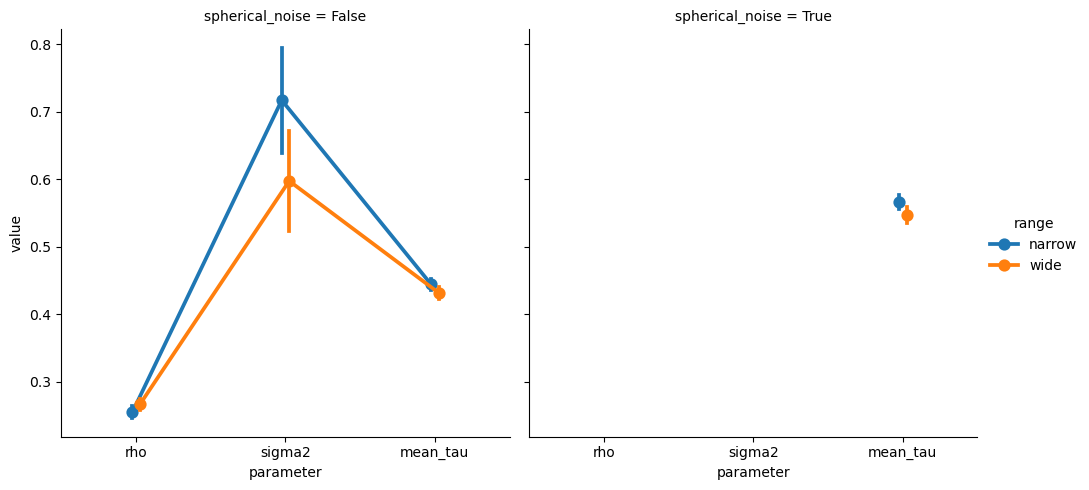

In [149]:
sns.catplot(x='parameter', y='value', data=sigma_pars.stack().to_frame('value'), hue='range', kind='point', dodge=True, col='spherical_noise', errorbar='se')

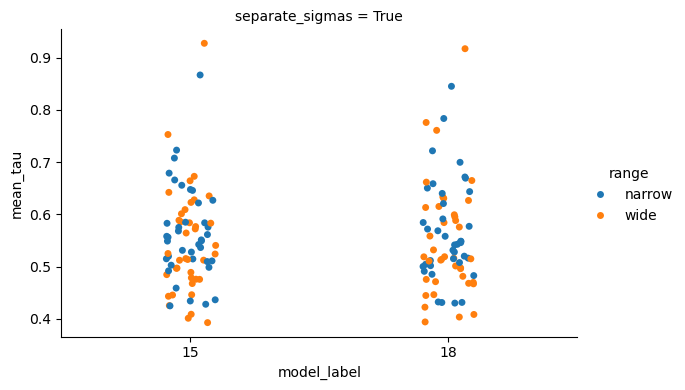

In [150]:
import seaborn as sns
mean_taus = taus.groupby(['subject', 'model_label', 'separate_sigmas', 'spherical_noise', 'range']).mean().to_frame('mean_tau')


sns.catplot(x='model_label', y='mean_tau', hue='range', col='separate_sigmas',
           data=mean_taus.xs(True, level='spherical_noise').reset_index(), kind='strip', height=4, aspect=1.5,)

In [151]:
import pingouin as pg


tmp = mean_taus.xs(True, level='spherical_noise').xs(15, level='model_label')


pg.pairwise_ttests(dv='mean_tau', between='range', data=tmp.reset_index(), subject='subject',)


/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/pingouin/pairwise.py:28: UserWarning: pairwise_ttests is deprecated, use pairwise_tests instead.
  warnings.warn("pairwise_ttests is deprecated, use pairwise_tests instead.", UserWarning)


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,BF10,hedges
0,range,narrow,wide,False,True,0.861091,76.0,two-sided,0.391896,0.324,0.193068
